In [1]:
import importlib
import models.xvae, models.dec, models.metrics, misc.dataset, misc.helpers
importlib.reload(models.xvae)
importlib.reload(models.dec)
importlib.reload(models.metrics)
importlib.reload(misc.dataset)
importlib.reload(misc.helpers)

from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.xvae import xvae
from models.dec import XDEC
from models.metrics import calculate_metrics

data = get_data()
x_num = normalizeRNA(data['rnanp'])
x_bin = data['clin']

ae = xvae(s1_input_size=x_num.shape[1], s2_input_size=x_bin.shape[1], ls=8)
ae.build_model()
ae.train(x_num, x_bin)

xdec = XDEC(ae, n_clusters=2)
y_pred, y_proba, centroids, z = xdec.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred)
print('acc={:.3f} ari={:.3f} nmi={:.3f}'.format(acc, ari, nmi))

import os, pandas as pd, torch
os.makedirs('results/manual_run_1', exist_ok=True)
ae.save_encoder('results/manual_run_1/encoder_xvae.pt')

emb = pd.DataFrame({'sample_id': data['sample_id']})
for j in range(z.shape[1]): emb['z{}'.format(j)] = z[:, j]
emb['mgs_level'] = data['label_classes'][data['y']]
emb.to_csv('results/manual_run_1/xdec_latent_embedding.csv', index=False)

# sanity check: confirm the checkpoint is in the new SHAP-compatible format
ckpt_check = torch.load('results/manual_run_1/encoder_xvae.pt', map_location='cpu')
assert isinstance(ckpt_check, dict) and 's1_input_size' in ckpt_check, (
    "encoder_xvae.pt is still the OLD format (bare state_dict) - "
    "restart the kernel and rerun this cell before using it in the SHAP notebook."
)
print('Encoder checkpoint OK, ready for SHAP:',
     {k: v for k, v in ckpt_check.items() if k != 'state_dict'})

Epoch 12/250 - loss: 1.0912
Epoch 24/250 - loss: 0.4752


Epoch 36/250 - loss: 0.3525
Epoch 48/250 - loss: 0.3533


Epoch 60/250 - loss: 0.2558
Epoch 72/250 - loss: 0.2170


Epoch 84/250 - loss: 0.2313
Epoch 96/250 - loss: 0.1919


Epoch 108/250 - loss: 0.1713
Epoch 120/250 - loss: 0.1881


...

Epoch 156/250 - loss: 0.1626
Epoch 168/250 - loss: 0.1416


Epoch 180/250 - loss: 0.1419
Epoch 192/250 - loss: 0.1414


Epoch 204/250 - loss: 0.1338
Epoch 216/250 - loss: 0.1343


Epoch 228/250 - loss: 0.1415
Epoch 240/250 - loss: 0.1339


Iter 0: acc = 0.66265, nmi = 0.07812, ari = 0.04600 ; loss=0.00000
Iter 50: acc = 0.66265, nmi = 0.07812, ari = 0.04600 ; loss=0.00000
delta_label 0.0 < tol 0.01
performed 50 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.66265, nmi = 0.07812, ari = 0.04600 ; loss=0.00000
acc=0.663 ari=0.046 nmi=0.078
Encoder checkpoint OK, ready for SHAP: {'s1_input_size': 81, 's2_input_size': 19, 'ds1': 48, 'ds2': 48, 'ds12': 48, 'ls': 8, 'dropout': 0.2, 'act': 'elu'}


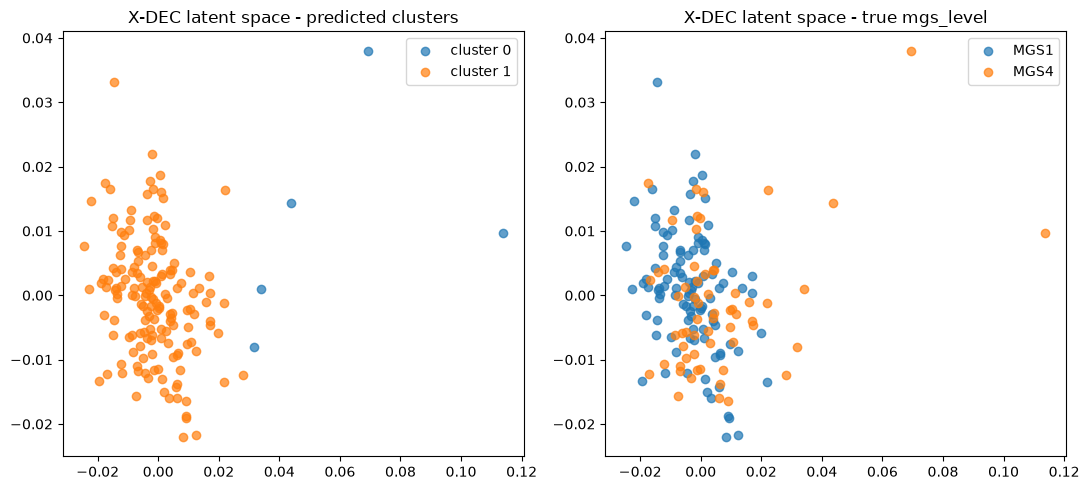

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

proj = PCA(n_components=2, random_state=5192).fit_transform(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(y_pred):
    mask = y_pred == c
    axes[0].scatter(proj[mask, 0], proj[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('X-DEC latent space - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj[mask, 0], proj[mask, 1], label=name, alpha=0.7)
axes[1].set_title('X-DEC latent space - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

mgs_level  MGS1  MGS4
cluster              
0             0     5
1           105    56


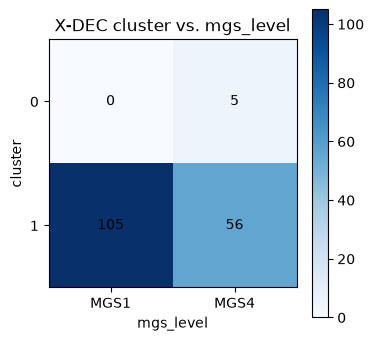

In [3]:
ct = pd.crosstab(pd.Series(y_pred, name='cluster'),
                 pd.Series(data['label_classes'][data['y']], name='mgs_level'))
print(ct)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel('mgs_level'); ax.set_ylabel('cluster')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center')
plt.colorbar(im)
plt.title('X-DEC cluster vs. mgs_level')
plt.show()

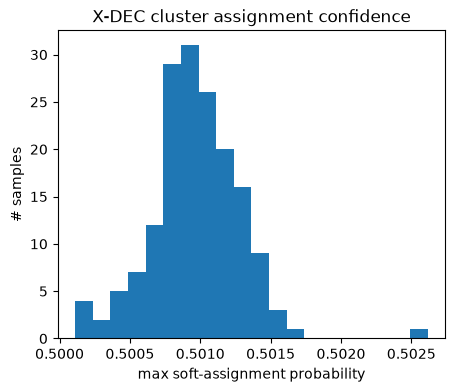

In [4]:
plt.figure(figsize=(5, 4))
plt.hist(y_proba.max(axis=1), bins=20)
plt.xlabel('max soft-assignment probability')
plt.ylabel('# samples')
plt.title('X-DEC cluster assignment confidence')
plt.show()

In [1]:
import importlib
import models.xvae, models.dec, models.metrics, misc.dataset, misc.helpers
importlib.reload(models.xvae)
importlib.reload(models.dec)
importlib.reload(models.metrics)
importlib.reload(misc.dataset)
importlib.reload(misc.helpers)

from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.xvae import xvae
from models.dec import XDEC
from models.metrics import calculate_metrics

data = get_data(clin_file="C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/Dataset/MetaSheet_1_4_17.csv", clinical_mode='full')
x_num = normalizeRNA(data['rnanp'])
x_bin = data['clin']

In [2]:
# ---- Load a previously saved encoder checkpoint and warm-start it ----
from models.xvae import load_xvae_model

encoder_path = "C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/X-DEC/results/manual_run_17_3/encoder_xvae.pt"  # <- point this at a saved checkpoint
ae_loaded = load_xvae_model(encoder_path)  # build_model() + load_state_dict() + eval() already done
a = ae_loaded.args
print('Loaded: ds1={} ds2={} ds12={} ls={} dropout={} act={} s1_input_size={} s2_input_size={}'.format(
    a.ds1, a.ds2, a.ds12, a.ls, a.dropout, a.act, a.s1_input_size, a.s2_input_size))

if a.s1_input_size != x_num.shape[1] or a.s2_input_size != x_bin.shape[1]:
    raise ValueError('Input widths (numeric={}, binary={}) do not match checkpoint '
                      '(s1_input_size={}, s2_input_size={}) - check clinical_mode matches '
                      'how this encoder was trained'.format(
                          x_num.shape[1], x_bin.shape[1], a.s1_input_size, a.s2_input_size))

Loaded: ds1=48 ds2=48 ds12=48 ls=4 dropout=0.2 act=elu s1_input_size=81 s2_input_size=16


In [3]:
# ---- Cluster on top of the loaded encoder, WITHOUT retraining it ----
# models/dec.py's XDEC in this copy is the frozen-encoder variant: it still
# runs the real K-means-init + Q/P self-training algorithm, it just never
# updates ae_loaded's weights - only the DECHead's cluster centers train.
from sklearn.metrics import adjusted_mutual_info_score

xdec_frozen = XDEC(ae_loaded, n_clusters=2)
y_pred_frozen, y_proba_frozen, centroids_frozen, z_frozen = xdec_frozen.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred_frozen)
ami = adjusted_mutual_info_score(data['y'], y_pred_frozen)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}  ami={:.3f}'.format(acc, ari, nmi, ami))

Iter 0: acc = 0.69880, nmi = 0.15633, ari = 0.10977 ; loss=0.00000
Iter 50: acc = 0.69880, nmi = 0.15633, ari = 0.10977 ; loss=0.00000
delta_label 0.0 < tol 0.01
performed 50 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.69880, nmi = 0.15633, ari = 0.10977 ; loss=0.00000
acc=0.699  ari=0.110  nmi=0.156  ami=0.150
